In [1]:
import alphapepttools as apt
import matplotlib as mpl
import matplotlib.pyplot as plt
import mudata as md
import muon
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway, false_discovery_control, tukey_hsd

/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(
/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
# Mirror the central alphapepttools plot settings (defaults.PlotSettings) onto matplotlib's
# global rcParams so notebook figures match the library defaults.
from alphapepttools.pl import defaults

_plot_config = defaults.plot_settings.to_dict()
plt.rcParams.update(
    {
        "font.size": _plot_config["font_sizes"]["medium"],
        "axes.titlesize": _plot_config["axes"]["title_size"],
        "axes.labelsize": _plot_config["axes"]["label_size"],
        "xtick.labelsize": _plot_config["axes"]["tick_size"],
        "ytick.labelsize": _plot_config["axes"]["tick_size"],
        "legend.fontsize": _plot_config["legend"]["font_size"],
        "legend.title_fontsize": _plot_config["legend"]["title_size"],
        "lines.linewidth": _plot_config["linewidths"]["medium"],
        "lines.markersize": _plot_config["marker_sizes"]["medium"],
        "figure.dpi": _plot_config["resolution"]["dpi"],
        "savefig.dpi": _plot_config["resolution"]["dpi"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

figure_output_dir = "../../../../assets/study_05_multimodal"

In [3]:
mdata = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/mudata/_core/io.py:495: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return func(elem)
/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)


In [4]:
total_explained_variance = pd.DataFrame(mdata.uns["mofa"]["variance"]).sum(axis=1)

## Factor activity

In [5]:
list(sns.color_palette("Accent").as_hex())

palette = ["#6CC196", "#beaed4", "#fdc086", "#555555", "#386cb0"]

In [6]:
DIM_X, DIM_Y = 0, 2

VAR_X = total_explained_variance.loc[DIM_X]
VAR_Y = total_explained_variance.loc[DIM_Y]

#### [Miniaturized figure for manuscript]

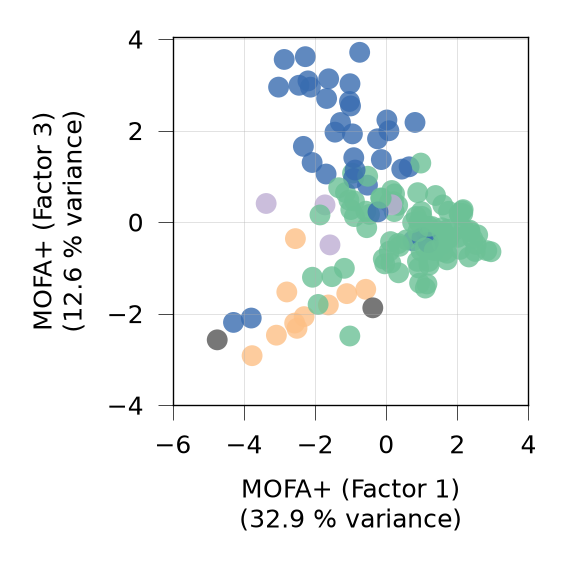

In [7]:
# Keep only the spine/axis styling that defaults.PlotSettings does not govern;
# font sizes and weights now follow the global rcParams derived from defaults.
plot_params = {
    "axes.linewidth": 1.0,
}

with mpl.rc_context(plot_params):
    fig, ax = apt.pl.create_figure(1, 1, figsize=("0.5", "0.5"))
    muon.pl.embedding(
        mdata,
        basis="X_mofa",
        dimensions=(DIM_X, DIM_Y),
        ax=ax[0],
        show=False,
        alpha=0.8,
        size=100,
        color="who2015_histology",
        title="",
        palette=palette,
        zorder=1,
    )
    xmin, xmax = ax[0].get_xlim()
    ymin, ymax = ax[0].get_ylim()

    ax[0].set_xticks(np.arange(np.floor(xmin), xmax + 1, 2))
    ax[0].set_yticks(np.arange(np.floor(ymin), ymax + 1, 2))
    ax[0].grid(visible=True, which="major", alpha=0.5, zorder=-np.inf)

    legend = ax[0].legend()
    handles, labels = ax[0].get_legend_handles_labels()
    legend.remove()

    ax[0].set_xlabel(f"MOFA+ (Factor {DIM_X + 1})\n({VAR_X:.1f} % variance)")
    ax[0].set_ylabel(f"MOFA+ (Factor {DIM_Y + 1})\n({VAR_Y:.1f} % variance)")

# fig.savefig("../../../../assets/study_04_multimodal/mofa-embedding_tiny.png", bbox_inches="tight", transparent=True)

apt.pl.save_figure(
    fig = fig,
    filename = "mofa-embedding_tiny.png",
    output_dir = figure_output_dir,
    dpi = 600,
    transparent = True,
)

plt.show()

/var/folders/17/vmd1w1fd6fq60l0jx7vjsrr40000gn/T/ipykernel_30655/1032467088.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


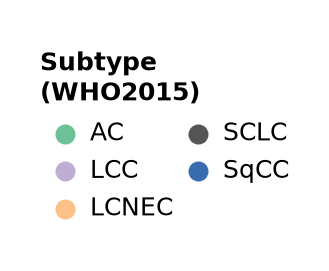

In [8]:
for handle in handles:
    handle.set_sizes([20])

fontsize = 6


fig, axm = apt.pl.create_figure(1, 1, figsize=("0.25", "0.25"))
ax = axm.next()

ax.legend(
    handles,
    labels,
    loc="center",
    title="Subtype\n(WHO2015)",
    title_fontproperties={"weight": "bold", "size": fontsize},
    alignment="left",
    fontsize=fontsize,
    facecolor="#ffffff",
    framealpha=0.3,
    ncols=2,
    columnspacing=0.0,
    frameon=False,
    handletextpad=0.0,
)
ax.set_axis_off()

plt.tight_layout()

apt.pl.save_figure(
    fig = fig,
    filename = "mofa-embedding.legend.png",
    output_dir = figure_output_dir,
    dpi = 600,
    transparent = True,
)

plt.show()

## Statistical significance

In [9]:
mofa_factors = mdata.obs.merge(
    pd.DataFrame(mdata.obsm["X_mofa"], index=mdata.obs_names),
    left_index=True,
    right_index=True,
)

mofa_factors

,proteome_subtype,age,sex,previous_histology,who2015_histology,smokingstatus,smokingstatus_binary,os_years,osbin,stroma_estimate,...,15,16,17,18,19,20,21,22,23,24
LU1155,6,76.334018,F,SqCC,SqCC,Former,Smoker,8.676249,0,0.683484,...,-0.002188,-0.364837,0.209032,0.271484,-0.233919,0.021200,-0.435827,-0.190506,0.264377,1.352616
LU775,6,75.000000,M,SqCC,SqCC,Former,Smoker,8.889802,1,0.309297,...,-0.004476,-0.034458,0.000988,0.288057,0.016694,0.291434,-0.095282,0.168794,0.325867,-7.108351
LU87,3,70.000000,F,AC,AC,Never_smoker,Never_smoker,9.111567,1,0.902676,...,-0.591306,0.134224,-0.305525,0.180238,-0.012061,0.207522,0.247089,-0.252140,0.116586,0.000880
LU1132,3,49.845311,F,AC,AC,Former,Smoker,0.969199,1,1.380401,...,1.229745,0.137473,0.260421,-0.003973,0.009909,0.052238,-0.105675,0.109575,-0.219736,-1.127071
LU876,3,44.000000,M,AC,AC,Current,Smoker,12.761123,1,0.500211,...,0.733127,-0.202005,0.306502,-0.000440,0.001773,-0.039903,0.007134,-0.157413,-0.339166,0.246782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LU820,3,74.300000,M,LCC,SqCC,Current,Smoker,1.138946,1,1.192257,...,0.779694,0.256530,0.092571,-0.038837,0.130973,0.289339,0.001751,0.317246,-0.258348,0.037912
LU1124,6,84.000000,F,SqCC,SqCC,Never_smoker,Never_smoker,9.100616,0,0.859762,...,0.447155,0.001481,0.039888,-0.084003,0.073102,-0.116852,0.000573,-0.132935,0.003707,0.177985
LU1166,6,77.817933,M,SqCC,SqCC,Current,Smoker,3.750856,1,0.280955,...,-0.473764,-0.322267,-0.121599,0.077771,0.004837,-0.024347,0.002717,0.569609,0.363593,0.924383
LU1126,1,66.729637,M,AC,AC,Current,Smoker,2.321697,1,0.491897,...,0.904161,-0.345299,-0.117254,0.000752,-0.001377,0.672954,0.000227,0.211029,0.580467,0.673063


### ANOVA

Test for significant differentces between histological conditions across all factors (25) and correct for multiple testing via BH. We assume normality of the factor activities as they are modelled as normal distribution in the MOFA+ model.

In [10]:
anova_results = []

groups = mofa_factors.groupby("who2015_histology", observed=True)

for factor in range(25):
    res = f_oneway(*[groups.get_group(group)[factor].to_list() for group in groups.groups.keys()], equal_var=False, nan_policy="raise")

    anova_results.append(
        {"factor": factor, "statistic": res.statistic, "p_value": res.pvalue}
    )

anova_results = pd.DataFrame(anova_results)
anova_results["fdr"] = false_discovery_control(anova_results["p_value"], method="bh")
anova_results["neg_log10_fdr"] = -1*np.log10(anova_results["fdr"])

anova_results

,factor,statistic,p_value,fdr,neg_log10_fdr
0,0,24.177555,0.001046,0.008717,2.059640
1,1,1.259504,0.384517,0.612824,0.212664
2,2,27.525456,0.000567,0.007092,2.149232
3,3,11.009643,0.007408,0.030867,1.510509
4,4,7.095937,0.007377,0.030867,1.510509
5,5,1.675581,0.257151,0.535731,0.271053
6,6,7.650142,0.015283,0.049548,1.304974
7,7,1.439636,0.320992,0.573200,0.241693
8,8,2.637691,0.116537,0.323713,0.489840
9,9,5.730416,0.004385,0.027407,1.562133


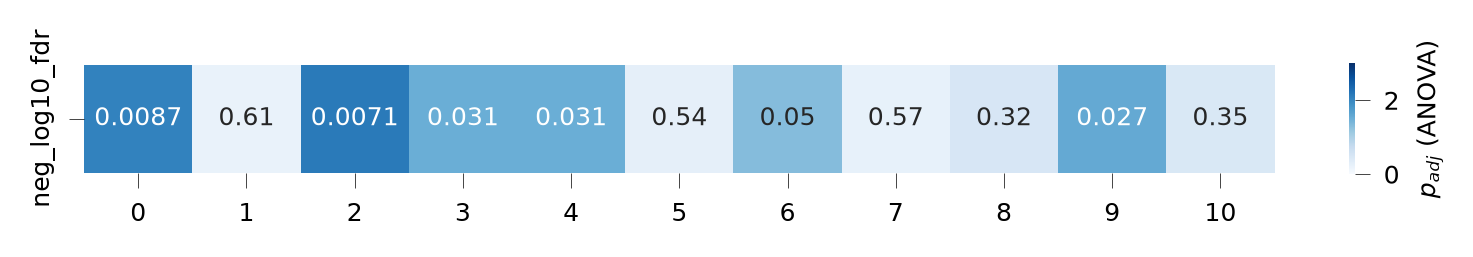

In [11]:
sns.heatmap(anova_results.loc[:10, ["neg_log10_fdr"]].T, square=True, vmin=0, vmax=3, cmap="Blues", annot=anova_results.loc[:10, ["fdr"]].T, fmt=".2g", cbar_kws={"shrink": 0.1, "label": "$p_{adj}$ (ANOVA)"})
plt.show()

/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


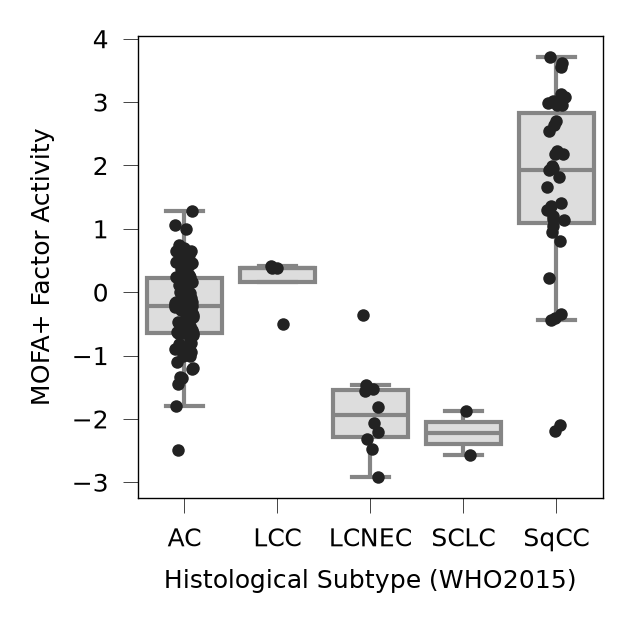

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
sns.boxplot(mofa_factors, x="who2015_histology", y=2, fliersize=0, ax=ax, color="#dddddd")
sns.stripplot(mofa_factors, x="who2015_histology", y=2, ax=ax, color="#222222", size=3)
ax.set_ylabel("MOFA+ Factor Activity")
ax.set_xlabel("Histological Subtype (WHO2015)")

plt.show()

Test differences between groups for most significantly different factor in the top 10 factors with Tukey's HSD:

In [13]:
factor = 2 # 0-indexing in the dataframe
res = tukey_hsd(*[groups.get_group(group)[factor].to_list() for group in groups.groups.keys()], equal_var=False)
pd.DataFrame(res.pvalue, index=groups.groups.keys(), columns=groups.groups.keys())

,AC,LCC,LCNEC,SCLC,SqCC
AC,1.000000e+00,0.504120,1.961839e-04,0.213017,6.110480e-08
LCC,5.041203e-01,1.000000,7.843726e-04,0.097082,4.332514e-03
LCNEC,1.961839e-04,0.000784,1.000000e+00,0.895024,5.380540e-11
SCLC,2.130168e-01,0.097082,8.950243e-01,1.000000,2.716644e-02
SqCC,6.110480e-08,0.004333,5.380540e-11,0.027166,1.000000e+00
